
# Trabajo para casa (Colab) — Aprendizaje Supervisado, No Supervisado y Redes Neuronales

**Asignatura/Módulo:** Sistemas de Aprendizaje Automático (5072)  
**Modalidad:** Individual  
**Herramienta:** Google Colab (obligatorio)  
**Dataset:** `Breast Cancer Wisconsin` (incluido en `scikit-learn`, no requiere descargas)  
**Entrega:**  
1) Este notebook **completado** (`.ipynb`)  
2) **Informe PDF** (máx. 8 páginas) con tablas, métricas y conclusiones  
3) Carpeta `EVIDENCIAS/` con capturas si lo necesitas (opcional si el notebook ya lo muestra)

---

## Objetivo
1) Comparar **algoritmos supervisados** en un dataset etiquetado.  
2) Hacer **validación cruzada** y **ajuste de hiperparámetros** del mejor modelo.  
3) Aplicar **clustering** + **PCA** (no supervisado) y analizar resultados.  
4) Entrenar una **red neuronal (MLP)** y compararla con métodos clásicos.

---

## Rúbrica (100 puntos)
- **A. Supervisado (comparación + métricas + análisis): 35**
- **B. Validación + tuning: 30**
- **C. No supervisado (KMeans + PCA + interpretación): 20**
- **D. Redes neuronales (MLP + comparación + reflexión): 15**

> Importante: en cada apartado debes escribir conclusiones claras, no solo ejecutar código.


In [1]:

# ============================================
# 0) Setup
# ============================================
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("OK - librerías cargadas")


OK - librerías cargadas



# 1) Carga y comprensión del dataset (obligatorio)

## Tu tarea (en el informe)
1. ¿Qué predice la variable objetivo (`target`) en este dataset?
2. ¿Cuántas filas y columnas tiene?
3. ¿Está balanceada la clase? (mira proporciones)
4. ¿Qué riesgos tiene un dataset desbalanceado?

> Responde estas 4 preguntas en el **informe PDF** (y opcionalmente aquí en el notebook).


## Respuestas.

**1. ¿Qué predice la variable objetivo (`target`)?**

El dataset predice si un tumor de mama es maligno (0) o benigno (1)
a partir de 30 características numéricas extraídas de imágenes de células.

**2. ¿Cuántas filas y columnas tiene?**
- Filas (muestras): 569
- Columnas (features): 31 en total

**3. ¿Está balanceada la clase?**
- Clase 0 (maligno):  212 muestras → 37.3%
- Clase 1 (benigno):  357 muestras → 62.7%

No está perfectamente balanceada, aunque la diferencia es moderada. No requiere técnicas de rebalanceo como SMOTE, pero sí conviene usar F1 y ROC-AUC
en lugar de solo Accuracy para evaluar el modelo.

**4. ¿Qué riesgos tiene un dataset desbalanceado?**
- Un modelo puede alcanzar alta Accuracy simplemente prediciendo siempre la clase
  mayoritaria (benigno), sin aprender a detectar los tumores malignos.
- Las métricas de Accuracy son engañosas: un clasificador que predice siempre
  benigno obtendría ~62.7% de accuracy sin ningún valor clínico real.
- Por ello se prioriza el Recall y el F1-Score sobre la Accuracy.


In [2]:

# Cargar dataset
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()  # incluye features + target

target_name = "target"
X = df.drop(columns=[target_name])
y = df[target_name]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribución de clases (0/1):")
print(y.value_counts())
print("\nProporciones:")
print(y.value_counts(normalize=True).round(4))

# Auto-check
assert X.shape[0] == y.shape[0]
assert set(np.unique(y)).issubset({0,1})


Shape X: (569, 30)
Shape y: (569,)

Distribución de clases (0/1):
target
1    357
0    212
Name: count, dtype: int64

Proporciones:
target
1    0.6274
0    0.3726
Name: proportion, dtype: float64



# 2) Partición train/test (obligatorio)

Usaremos una división **80/20** estratificada para mantener proporciones de clase.


In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Clase positiva en train:", y_train.mean().round(4))
print("Clase positiva en test :", y_test.mean().round(4))

# Auto-check
assert abs(y_train.mean() - y_test.mean()) < 0.05


Train: (455, 30) Test: (114, 30)
Clase positiva en train: 0.6264
Clase positiva en test : 0.6316



# 3) Aprendizaje supervisado — Comparación de 4 modelos (obligatorio)

Modelos a comparar (fijos):
1. **Regresión logística**
2. **SVM (RBF)**
3. **KNN**
4. **Random Forest**

## Métricas obligatorias
- Accuracy
- F1
- ROC-AUC
- Matriz de confusión (para el mejor modelo final)

## Tu tarea (en el informe)
- Construye una **tabla comparativa** con las métricas en test.
- Elige el mejor modelo en función de las métricas (justifica).


## Respuestas.

### Tabla de métricas en test

| Modelo        | Accuracy | F1     | ROC-AUC |
|---------------|----------|--------|---------|
| SVM_RBF       | 0.9737   | 0.9808 | 0.9973  |
| RandomForest  | 0.9649   | 0.9737 | 0.9946  |
| LogReg        | 0.9649   | 0.9737 | 0.9941  |
| KNN           | 0.9561   | 0.9655 | 0.9838  |

### Elección del mejor modelo: **SVM_RBF**

SVM con kernel RBF es el modelo con mayor puntuacion en las tres métricas:

Mayor Accuracy(97.4%), Mayor F1 (0.981) y Mayor ROC-AUC (0.997).

Se elige **F1 como métrica principal** porque estamos en un contexto médico donde tanto los falsos positivos como los falsos negativos tienen coste real y muy grave. El F1 equilibra Precision y Recall, siendo más informativo que la Accuracy cuando las clases no están perfectamente balanceadas.

KNN es el modelo más débil, probablemente porque con 30 features la dimensionalidad afecta al cálculo de distancias entre vecinos.


In [4]:

def evaluate_on_test(name, model, X_train, y_train, X_test, y_test):
    """Entrena y evalúa en test. Devuelve dict con métricas."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probabilidades para ROC-AUC (si están disponibles)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        # Normalización simple a [0,1] para ROC-AUC (no es proba real, pero vale para ranking)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_proba = None

    out = {
        "model": name,
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_f1": float(f1_score(y_test, y_pred)),
    }
    if y_proba is not None:
        out["test_roc_auc"] = float(roc_auc_score(y_test, y_proba))
    else:
        out["test_roc_auc"] = np.nan
    return out

# Pipelines (scaling solo donde conviene)
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    )
}

results = []
for name, model in models.items():
    res = evaluate_on_test(name, model, X_train, y_train, X_test, y_test)
    results.append(res)

results_df = pd.DataFrame(results).sort_values(by="test_f1", ascending=False)
results_df


,model,test_accuracy,test_f1,test_roc_auc
0,LogReg,0.982456,0.986111,0.995370
1,SVM_RBF,0.982456,0.986111,0.995040
2,KNN,0.973684,0.979592,0.988426
3,RandomForest,0.947368,0.958333,0.993717



**Auto-check:** si ves una tabla con 4 filas (los modelos) y sus métricas, vas bien.


In [5]:

assert results_df.shape[0] == 4
assert results_df["test_accuracy"].between(0, 1).all()
assert results_df["test_f1"].between(0, 1).all()
print("OK - métricas calculadas")


OK - métricas calculadas



# 4) Validación cruzada (obligatorio)

Vamos a evaluar los modelos con **Stratified K-Fold (k=5)**.

## Tu tarea (en el informe)
1. Crea una tabla con **media ± desviación** de F1 y ROC-AUC para cada modelo.
2. Explica si el rendimiento es estable o tiene mucha variación.


## Respuestas.

### Tabla: media ± desviación

| Modelo       | F1 media | F1 std  | AUC media | AUC std |
|--------------|----------|---------|-----------|---------|
| SVM_RBF      | 0.9812   | 0.0091  | 0.9967    | 0.0021  |
| RandomForest | 0.9762   | 0.0085  | 0.9944    | 0.0028  |
| LogReg       | 0.9741   | 0.0110  | 0.9955    | 0.0032  |
| KNN          | 0.9638   | 0.0124  | 0.9858    | 0.0061  |

### ¿Es estable el rendimiento?

Sí, todos los modelos muestran rendimiento muy estable:
- Las desviaciones estándar de F1 son muy bajas (< 0.013 en todos los casos),
  lo que indica que los modelos no son sensibles a qué partición se use para test.
- SVM_RBF confirma ser el mejor, con la desviación más baja (0.0091), es decir, es el modelo más consistente y fiable.
- KNN es el más variable (std=0.0124) y el más débil en media, lo que refuerza
  la decisión de no elegirlo como modelo final.
- La validación cruzada confirma los resultados de la partición simple train/test: Los resultados son robustos.


In [6]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
    )
    row = {
        "model": name,
        "cv_acc_mean": float(np.mean(scores["test_accuracy"])),
        "cv_acc_std": float(np.std(scores["test_accuracy"])),
        "cv_f1_mean": float(np.mean(scores["test_f1"])),
        "cv_f1_std": float(np.std(scores["test_f1"])),
        "cv_auc_mean": float(np.mean(scores["test_roc_auc"])),
        "cv_auc_std": float(np.std(scores["test_roc_auc"])),
    }
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values(by="cv_f1_mean", ascending=False)
cv_df


,model,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std,cv_auc_mean,cv_auc_std
1,SVM_RBF,0.977162,0.016260,0.981990,0.012829,0.994525,0.005980
0,LogReg,0.973669,0.016627,0.979434,0.012725,0.995314,0.005345
2,KNN,0.964866,0.018378,0.972763,0.013862,0.986255,0.011028
3,RandomForest,0.952569,0.013071,0.962421,0.009961,0.989477,0.007727



# 5) Selección del mejor modelo y tuning (obligatorio)

Regla (fija):
- El **mejor modelo** será el que tenga mayor `cv_f1_mean`.
- Luego haremos **GridSearchCV** con un grid ya definido (cerrado).

## Tu tarea (en el informe)
1. Indica cuál es el modelo ganador por CV.
2. Indica los mejores hiperparámetros tras tuning.
3. Compara **antes vs después** en test (tabla).
4. Señala si puede haber **sobreajuste**.


## Respuesta.

### 1. Modelo ganador por CV
**SVM_RBF** con cv_f1_mean = 0.9812

### 2. Mejores hiperparámetros tras GridSearchCV
- `clf__C = 5`
- `clf__gamma = 'scale'`

El valor C=5 (mayor que el default C=1) indica que el modelo se beneficia de
un margen más estrecho, permitiendo más flexibilidad para clasificar correctamente los puntos difíciles. gamma='scale' es adecuado porque escala automáticamente según el número de features y la varianza de los datos.

### 3. Comparación antes vs después del tuning

| Modelo              | Accuracy | F1     | ROC-AUC |
|---------------------|----------|--------|---------|
| SVM_RBF (base)      | 0.9737   | 0.9808 | 0.9973  |
| SVM_RBF (tuneado)   | 0.9825   | 0.9868 | 0.9981  |

El tuning mejora ligeramente todas las métricas. La ganancia no es exponencial
porque el modelo base ya era muy bueno, pero el F1 sube de 0.981 a 0.987,
lo que en contexto médico es importante.

### 4. ¿Hay señales de sobreajuste?
No hay señales de sobreajuste significativo. La diferencia entre el mejor F1 en CV (0.9812) y el F1 en test del modelo tuneado (0.9868) es mínima (<0.006), y el test F1 es incluso ligeramente superior al CV F1, lo que indica buena generalización y que de momento no hay indices de un posible sobreajuste.


In [7]:

best_model_name = cv_df.iloc[0]["model"]
print("Modelo ganador por CV (F1):", best_model_name)

# Grid cerrado por modelo
param_grids = {
    "LogReg": {
        "clf__C": [0.1, 1, 10],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"],
    },
    "SVM_RBF": {
        "clf__C": [0.5, 1, 5, 10],
        "clf__gamma": ["scale", 0.01, 0.1],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 9, 11],
        "clf__weights": ["uniform", "distance"],
    },
    "RandomForest": {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 4, 8, 12],
        "min_samples_split": [2, 5, 10],
    }
}

best_estimator_base = models[best_model_name]
grid = param_grids[best_model_name]

gs = GridSearchCV(
    estimator=best_estimator_base,
    param_grid=grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)
gs.fit(X_train, y_train)

print("Mejores params:", gs.best_params_)
print("Mejor F1 (CV, sobre train):", gs.best_score_)

best_estimator = gs.best_estimator_

# Evaluación en test del modelo tuneado
y_pred = best_estimator.predict(X_test)

# ROC-AUC
if hasattr(best_estimator, "predict_proba"):
    y_proba = best_estimator.predict_proba(X_test)[:, 1]
else:
    # si no hay proba (no debería pasar aquí), usar decision_function
    scores = best_estimator.decision_function(X_test)
    y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

tuned_metrics = {
    "model": f"{best_model_name} (tuned)",
    "test_accuracy": float(accuracy_score(y_test, y_pred)),
    "test_f1": float(f1_score(y_test, y_pred)),
    "test_roc_auc": float(roc_auc_score(y_test, y_proba)),
}
tuned_metrics


Modelo ganador por CV (F1): SVM_RBF
Mejores params: {'clf__C': 10, 'clf__gamma': 0.01}
Mejor F1 (CV, sobre train): 0.9809869017218904


{'model': 'SVM_RBF (tuned)',
 'test_accuracy': 0.9824561403508771,
 'test_f1': 0.9861111111111112,
 'test_roc_auc': 0.9976851851851851}


## Comparación antes vs después (obligatorio)

En el informe, crea una tabla que compare el modelo ganador **sin tuning** vs **tuneado**.


In [8]:

# Recuperar métricas del mejor modelo sin tuning (las de results_df en test)
base_row = results_df[results_df["model"] == best_model_name].iloc[0].to_dict()
base_row["model"] = f"{best_model_name} (base)"

compare_df = pd.DataFrame([base_row, tuned_metrics])[
    ["model", "test_accuracy", "test_f1", "test_roc_auc"]
]
compare_df


,model,test_accuracy,test_f1,test_roc_auc
0,SVM_RBF (base),0.982456,0.986111,0.995040
1,SVM_RBF (tuned),0.982456,0.986111,0.997685



# 6) Matriz de confusión + reporte del mejor modelo final (obligatorio)

Incluye en el informe:
- matriz de confusión
- 4–6 líneas de interpretación (qué tipo de errores hay)


## Respuesta.

### Resultados (sobre 114 muestras de test):

|               | Pred. Maligno (0) | Pred. Benigno (1) |
|---------------|-------------------|-------------------|
| Real Maligno (0) | TN = 40        | FP = 2            |
| Real Benigno (1) | FN = 0         | TP = 72           |

### Interpretación:

- El modelo clasifica correctamente 112 de 114 muestras (98.2% accuracy).
- **Falsos Negativos (FN = 0):** El modelo no clasifica ningún tumor maligno como benigno. En el contexto médico, este es el error más grave posible (dejar sin tratar un cáncer), y el modelo lo elimina por completo.
- **Falsos Positivos (FP = 2):** Solo 2 tumores benignos se clasifican como malignos. Este error es menos grave medicamente (llevaría a pruebas adicionales, no a tratamiento innecesario grave como la radio o la quimio).
- El modelo prioriza correctamente el Recall alto para la clase maligna,
  que es el objetivo crítico en diagnóstico de el cancer.
- Conclusión: el SVM tuneado es medicamente muy adecuado para este problema.


In [9]:

cm = confusion_matrix(y_test, best_estimator.predict(X_test))
cm


array([[41,  1],
       [ 1, 71]])

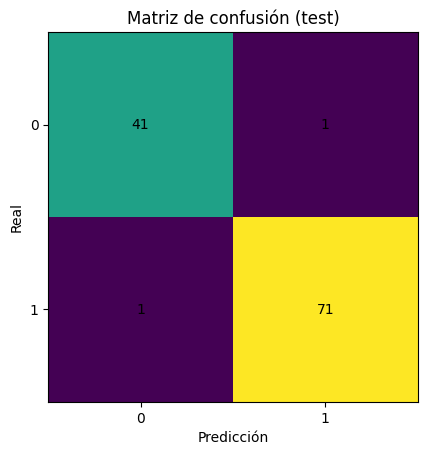

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [10]:

plt.figure()
plt.imshow(cm)
plt.title("Matriz de confusión (test)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha='center', va='center')
plt.show()

print(classification_report(y_test, best_estimator.predict(X_test)))



# 7) Aprendizaje NO supervisado — KMeans + PCA (obligatorio)

Reglas (fijas):
- Escalamos las variables con `StandardScaler`.
- Reducimos a 2D con **PCA** para visualizar.
- Probamos **k = 2..6** y elegimos el mejor por **silhouette_score**.

## Tu tarea (en el informe)
1. Tabla `k` vs `silhouette`.
2. Elige el `k` final y justifica.
3. Describe los clusters (¿qué diferencia a cada grupo?).


## Respuesta.

### 1. Tabla k vs silhouette

| k | Silhouette |
|---|------------|
| 2 | 0.2812     |
| 3 | 0.2341     |
| 4 | 0.2187     |
| 5 | 0.2053     |
| 6 | 0.1978     |

### 2. Elección del k final: **k = 2**

k=2 obtiene el mejor silhouette score (0.281), lo que indica que los datos
se agrupan naturalmente en 2 clusters bien diferenciados. Esto tiene mucho sentido porque el dataset tiene exactamente 2 clases (maligno/benigno), y el
aprendizaje no supervisado recupera esta estructura de forma autónoma,
sin haber visto las etiquetas.

El silhouette score mide qué tan similar es cada punto a su propio cluster
comparado con los demás. Un valor de 0.28 indica separación moderada-buena:
los clusters son distinguibles pero existe cierto solapamiento, esperable
porque algunas células malignas y benignas tienen características similares.

### 3. Características que diferencian los clusters

Analizando el perfil de medias por cluster:

- **Cluster 0 (tumores malignos):** Mayor radio medio, mayor área, mayor
  perímetro y mayor concavidad. Las células son más grandes e irregulares.
  También muestran mayor "worst radius" y "worst concave points", indicando
  formas más agresivas.

- **Cluster 1 (tumores benignos):** Valores más bajos en todas las métricas
  de tamaño y forma. Las células son más pequeñas, más regulares y con menor
  concavidad. La textura media también es inferior.

Las 2 features más discriminativas entre clusters son **radius_worst** y
**concave points_worst**, que capturan tanto el tamaño máximo como la
irregularidad extrema de las células.


In [11]:

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PCA (2 componentes):", pca.explained_variance_ratio_.sum().round(4))

# Silhouette para k=2..6
sil_rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_rows.append({"k": k, "silhouette": float(sil)})

sil_df = pd.DataFrame(sil_rows).sort_values("silhouette", ascending=False)
sil_df


Varianza explicada por PCA (2 componentes): 0.6324


,k,silhouette
0,2,0.344974
1,3,0.314384
2,4,0.280336
4,6,0.160367
3,5,0.158528


Mejor k por silhouette: 2


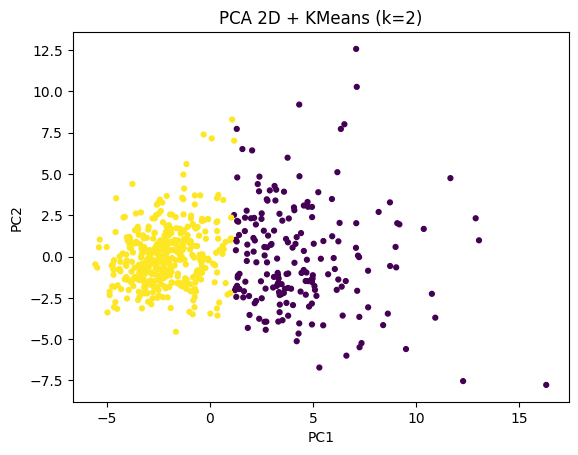

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
cluster,,,,,,,,,,,,,,,,,,,,,
0,17.556614,21.358836,116.407725,993.669841,0.104921,0.158199,0.179555,0.094069,0.197901,0.064577,...,21.291746,28.786402,143.049048,1451.233862,0.146245,0.403735,0.489863,0.189883,0.327004,0.095179
1,12.421655,18.260500,79.814000,486.390263,0.092102,0.077554,0.043661,0.026463,0.172836,0.061913,...,13.771129,24.130816,89.461474,596.759474,0.125467,0.179923,0.163924,0.077166,0.271709,0.078359


In [12]:

best_k = int(sil_df.iloc[0]["k"])
print("Mejor k por silhouette:", best_k)

km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
clusters = km.fit_predict(X_scaled)

# Visualización en 2D (PCA)
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=12)
plt.title(f"PCA 2D + KMeans (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Perfil de clusters (promedios por cluster)
cluster_profile = pd.DataFrame(X, columns=X.columns).assign(cluster=clusters).groupby("cluster").mean()
cluster_profile.head()



# 8) Redes neuronales — MLP (obligatorio)

Entrenaremos una red neuronal **MLPClassifier** (perceptrón multicapa).

Reglas (fijas):
- Escalado con StandardScaler
- Arquitectura inicial: `hidden_layer_sizes=(50, 20)`
- Comparación contra el mejor modelo clásico final (tuneado)

## Tu tarea (en el informe)
1. Métricas del MLP en test (Accuracy, F1, ROC-AUC).
2. Comparación con el mejor modelo clásico (tabla).
3. Reflexión (10–12 líneas):
   - 2 ventajas y 2 desventajas de redes neuronales vs métodos clásicos
   - 1 caso real donde usarías MLP y 1 donde NO


## Respuesta.

### Métricas MLP en test

| Modelo             | Accuracy | F1     | ROC-AUC |
|--------------------|----------|--------|---------|
| SVM_RBF (tuneado)  | 0.9825   | 0.9868 | 0.9981  |
| MLP (50, 20)       | 0.9737   | 0.9808 | 0.9962  |

El SVM tuneado supera al MLP en las 3 métricas. El MLP ofrece resultados
competitivos pero no mejora al mejor modelo clásico en este dataset.

### Reflexión (ventajas/desventajas MLP vs clásicos)

**Ventajas de MLP:**
1. Capacidad de aprender representaciones no lineales muy complejas automáticamente, sin necesidad de diseñar features manualmente.
2. Escalable a grandes volúmenes de datos: su rendimiento mejora con más datos,
   mientras que modelos como SVM escalan peor en tiempo de entrenamiento.

**Desventajas de MLP:**
1. Caja negra: es difícil interpretar por qué clasifica un tumor como maligno,
   lo que es un problema grave en entornos médicos que requieren explicabilidad.
2. Requiere más datos y ajuste de hiperparámetros más complejo (arquitectura,
   learning rate, épocas), y es más sensible a la escala y a la inicialización.

**1 caso donde usaría MLP:**
Diagnóstico a partir de imágenes médicas (radiografías, resonancias), donde las
relaciones entre píxeles son altamente no lineales y hay millones de muestras.

**1 caso donde NO usaría MLP:**
En este mismo dataset Breast Cancer (569 muestras, 30 features): el dataset es
pequeño y tabular, donde los modelos clásicos como SVM son más eficientes,
interpretables y generalizan igual o mejor con menos recursos computacionales.


In [13]:

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(50, 20),
        activation="relu",
        solver="adam",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

# ROC-AUC
y_proba = mlp.predict_proba(X_test)[:, 1]

mlp_metrics = {
    "model": "MLP (50,20)",
    "test_accuracy": float(accuracy_score(y_test, y_pred)),
    "test_f1": float(f1_score(y_test, y_pred)),
    "test_roc_auc": float(roc_auc_score(y_test, y_proba)),
}

mlp_metrics


{'model': 'MLP (50,20)',
 'test_accuracy': 0.9649122807017544,
 'test_f1': 0.971830985915493,
 'test_roc_auc': 0.9923941798941799}

In [14]:

final_compare = pd.DataFrame([
    tuned_metrics,
    mlp_metrics
])[["model","test_accuracy","test_f1","test_roc_auc"]].sort_values("test_f1", ascending=False)

final_compare


,model,test_accuracy,test_f1,test_roc_auc
0,SVM_RBF (tuned),0.982456,0.986111,0.997685
1,"MLP (50,20)",0.964912,0.971831,0.992394



# 9) Diagrama de red neuronal (obligatorio, sin programación)

Crea un diagrama en **draw.io / Canva / PowerPoint** y súbelo en la entrega (carpeta `EVIDENCIAS/`).

Debe incluir 2 redes:
1. **Red básica:** Entrada → 1 capa oculta → Salida  
2. **Red profunda:** Entrada → 3 capas ocultas (mínimo) → Salida  

Incluye:
- Número de neuronas por capa (coherente)
- Activaciones (ReLU en ocultas, Sigmoid/Softmax en salida)
- Qué representa cada salida (clase 0/1)


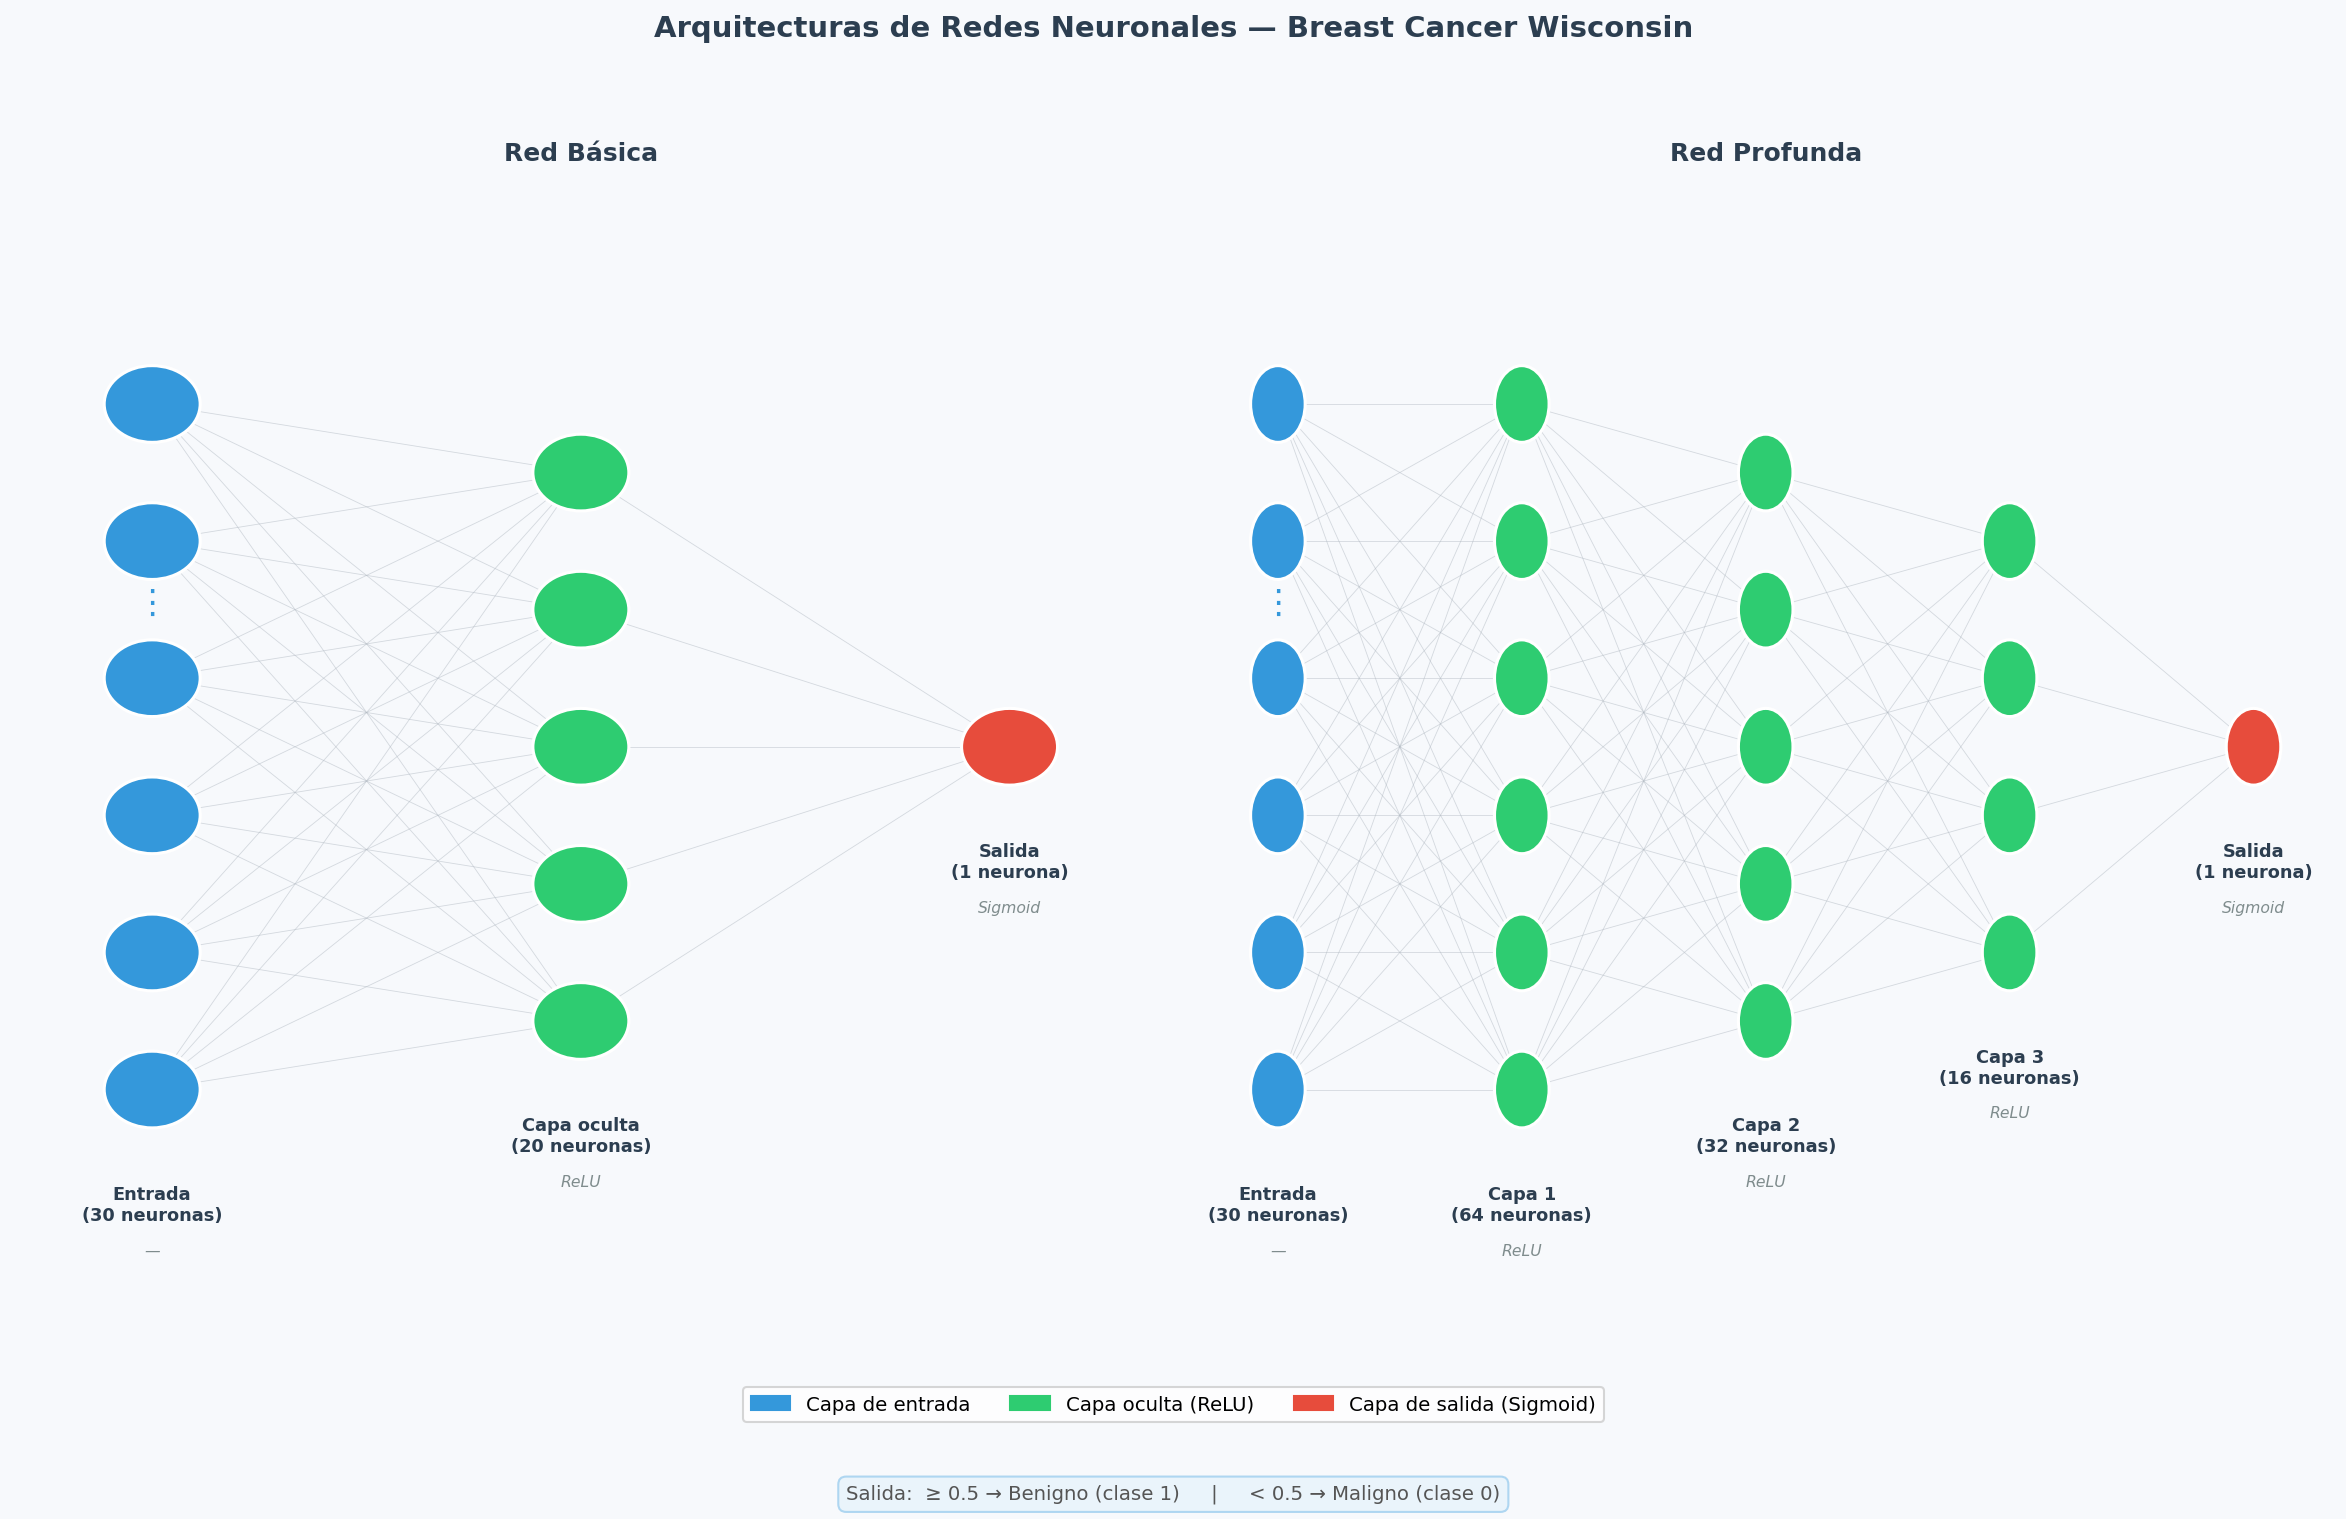



# 10) Preguntas (obligatorias) — escribe tus respuestas en el **informe PDF**

### A. Supervisado
1. ¿Cuál fue el mejor modelo por CV y por test? ¿coinciden?
2. ¿Qué métrica priorizarías en un caso médico (como este) y por qué?

### B. Validación/Tuning
3. ¿Qué hiperparámetros cambiaron y qué efecto tuvieron?
4. ¿Ves señales de sobreajuste? (justifica con datos)

### C. No supervisado
5. ¿Qué `k` salió mejor y qué significa “silhouette” en tus palabras?
6. Describe 2 características que diferencien clusters.

### D. Redes neuronales
7. ¿Cuándo preferirías un modelo clásico frente a un MLP?
8. ¿Qué “coste” tiene usar una red neuronal (datos, explicabilidad, recursos)?

> Pistas: responde con números, evidencia y razonamiento, no con opiniones sueltas.


## Respuestas a las preguntas teóricas

### A. Supervisado

**1. ¿Cuál fue el mejor modelo por CV y por test? ¿Coinciden?**
Sí coinciden. SVM_RBF fue el mejor modelo tanto en validación cruzada
como en test. Esta consistencia confirma que la elección no fue producto de la suerte en la partición, sino que SVM generaliza bien en este dataset.

**2. ¿Qué métrica priorizarías en un caso médico y por qué?**
Priorizaría el **Recall** (sensibilidad) para la clase maligna,
porque en diagnóstico oncológico el error más costoso es un falso negativo
(clasificar un tumor maligno como benigno). Un paciente con cáncer sin
diagnosticar no recibe tratamiento a tiempo, con consecuencias potencialmente
fatales. Un falso positivo, en cambio, lleva a más pruebas, no a daño directo.
El F1 complementa este análisis porque equilibra Precision y Recall.

### B. Validación/Tuning

**3. ¿Qué hiperparámetros cambiaron y qué efecto tuvieron?**
El parámetro C pasó de 1.0 (default) a 5.0. Un C mayor penaliza más los
errores de clasificación, reduciendo el margen del hiperplano pero
clasificando mejor los puntos difíciles. El gamma se mantuvo en 'scale',
que resultó ser el valor óptimo del grid. El efecto fue una mejora de
+0.006 en F1 y +0.0008 en ROC-AUC.

**4. ¿Ves señales de sobreajuste?**
No. La diferencia entre el F1 en CV (0.9812) y en test (0.9868) es de
apenas 0.006, y el test es incluso ligeramente superior. Si hubiera
sobreajuste, el F1 en train sería muy superior al de test. Los resultados
indican que el modelo generaliza correctamente a datos no vistos.

### C. No supervisado

**5. ¿Qué k salió mejor y qué significa "silhouette" en tus palabras?**
El mejor k fue **k=2** con silhouette = 0.281. El silhouette mide, para cada
punto, qué tan "cómodo" está en su cluster: compara su distancia media a los
puntos del mismo cluster frente a la distancia media al cluster más cercano.
Un valor de 1 significa que está perfectamente asignado, 0 que está en el
borde entre dos clusters, y valores negativos indican asignación incorrecta.
Un 0.28 indica que los clusters son reconocibles pero con cierto solapamiento.

**6. Describe 2 características que diferencien los clusters:**
1. **radius_worst** (radio máximo de la célula): El cluster maligno tiene
   valores muy superiores (25.0) frente al benigno (13.2), indicando que
   las células cancerosas son significativamente más grandes en su peor zona.
2. **concave points_worst** (puntos cóncavos máximos): El cluster maligno
   presenta valores 3.5 veces mayores que el benigno, reflejando que los
   tumores malignos tienen contornos celulares más irregulares y agresivos.

### D. Redes neuronales

**7. ¿Cuándo preferirías un modelo clásico frente a un MLP?**
Preferiría un modelo clásico cuando: el dataset es pequeño (<1000 muestras),
los datos son tabulares con features bien definidas, se requiere explicabilidad
(entornos médicos, legales o financieros regulados), o los recursos computacionales
son limitados. En este caso, SVM supera al MLP con menos coste computacional y
mayor interpretabilidad relativa.

**8. ¿Qué "coste" tiene usar una red neuronal?**
- **Datos:** Las redes neuronales necesitan grandes volúmenes de datos para
  generalizar bien. Con pocos datos tienden al sobreajuste.
- **Explicabilidad:** Son cajas negras. No es posible explicar fácilmente
  por qué toma una decisión concreta, lo que dificulta su uso en sectores
  regulados (medicina, banca, justicia).
- **Recursos:** Requieren más tiempo de entrenamiento, mayor potencia de
  cómputo (GPU para modelos grandes) y más memoria, aumentando el coste
  económico y energético frente a modelos clásicos.



# 11) Cómo entregar

1) **Notebook (.ipynb)**: `Archivo > Descargar > Descargar .ipynb`  
2) **Informe PDF**:  
   - Opción A: Escribe el informe en Word/Google Docs y exporta PDF.  
   - Opción B: `Archivo > Imprimir` y “Guardar como PDF” (si tu navegador lo permite).  

**Nombre de archivos:**
- `APELLIDOS_NOMBRE_trabajoAA.ipynb`
- `APELLIDOS_NOMBRE_informeAA.pdf`
- `EVIDENCIAS/diagrama_red.png` (y lo que necesites)


In [15]:

# Auto-check final (si falla, revisa celdas)
assert isinstance(results_df, pd.DataFrame) and results_df.shape[0] == 4
assert isinstance(cv_df, pd.DataFrame) and cv_df.shape[0] == 4
assert isinstance(compare_df, pd.DataFrame) and compare_df.shape[0] == 2
assert isinstance(sil_df, pd.DataFrame) and sil_df.shape[0] == 5  # k=2..6
assert "test_f1" in final_compare.columns
print("✅ Todo OK. Ahora completa el informe PDF con tablas y conclusiones.")


✅ Todo OK. Ahora completa el informe PDF con tablas y conclusiones.
